# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [4]:
import matplotlib.pyplot as plt
#import numpy as np
import pandas as pd

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [116]:
import matplotlib.pyplot as plt
import pandas as pd

path = 'data/datasets/'
tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
interactions = pd.read_parquet(path + 'interactions.parquet')

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

### Данных о треках

In [64]:
# общий обзор (и пустые значения)
display(tracks)
display(tracks.info())

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


None

In [ ]:
# проверка на дубликаты (необходимо преобразовать массивы в tuples для возможности хеширования)
pd.concat([
        tracks['track_id'], 
        tracks['albums'].apply(tuple),
        tracks['artists'].apply(tuple),
        tracks['genres'].apply(tuple)
    ], axis=1).duplicated().sum()

0

### Данных каталога

In [66]:
# общий обзор (и пустые значения)
display(catalog)
display(catalog.info(show_counts=True))

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   id      1812471 non-null  int64 
 1   type    1812471 non-null  object
 2   name    1812471 non-null  object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


None

In [ ]:
# проверка на дубликаты
catalog.duplicated().sum()

0

In [35]:
catalog.type.unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [73]:
display('album', catalog.query('type == "album"'))
display('artist', catalog.query('type == "artist"'))
display('artist', catalog.query('type == "artist"'))
display('track', catalog.query('type == "track"'))

'album'

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
658719,21458141,album,The Lazy Singles
658720,21458207,album,Jackie Mittoo Anthology
658721,21458968,album,Master Composers: Johann Sebastian Bach
658722,21459622,album,Take the Money and Run


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'artist'

,id,type,name
658724,4,artist,Kenny Dorham
658725,5,artist,Max Roach
658726,7,artist,Francis Rossi
658727,9,artist,Status Quo
658728,12,artist,Phil Everly
...,...,...,...
812300,16093680,artist,Los Tiburones
812301,16097398,artist,AMELI
812302,16098445,artist,2GANGSTA
812303,16099125,artist,Daria


'track'

,id,type,name
812471,26,track,Complimentary Me
812472,38,track,Momma's Boy
812473,135,track,Atticus
812474,136,track,24 Hours
812475,138,track,Don't Upset The Rhythm (Go Baby Go)
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


### Данных взаимодействий

In [77]:
# общий обзор (и пустые значения)
display(interactions)
display(interactions.info(show_counts=True))

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Non-Null Count      Dtype         
---  ------      --------------      -----         
 0   user_id     222629898 non-null  int32         
 1   track_id    222629898 non-null  int32         
 2   track_seq   222629898 non-null  int16         
 3   started_at  222629898 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


None

In [ ]:
# почему индекс всего до 291 ?
display(interactions.index[:30])
display(interactions.head(30))

# понятно - сборная куча историй по каждому пользователю, без переиндексации финального датасета

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25,  0,  1,  2,  3],
      dtype='int64')

,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
5,0,590803,6,2022-07-25
6,0,597196,7,2022-07-25
7,0,597199,8,2022-07-25
8,0,1750835,9,2022-07-30
9,0,1750843,10,2022-08-05


In [ ]:
# проверим за какой диапазон дат есть история, и нет ли выбросов

interactions.started_at.min(), interactions.started_at.max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

### Проверка - есть ли треки с неизвестными исполнителями, альбомами, жанрами

In [117]:
# проверка записей, у которых не заданы связанные сущности

track_empty_albums = tracks[tracks['albums'].apply(len) == 0]
track_empty_arists = tracks[tracks['artists'].apply(len) == 0]
track_empty_genres = tracks[tracks['genres'].apply(len) == 0]
print(f'tracks with unknown albums = {track_empty_albums.shape[0]}')
print(f'tracks with unknown arists = {track_empty_arists.shape[0]}')
print(f'tracks with unknown genres = {track_empty_genres.shape[0]}')
print(f'total number of track with unknown items = {track_empty_albums.shape[0] + track_empty_arists.shape[0] + track_empty_genres.shape[0]}')

tracks with unknown albums = 18
tracks with unknown arists = 15369
tracks with unknown genres = 3687
total number of track with unknown items = 19074


In [118]:
# сформируем плоское представление записей, чтобы проверить корректность ссылок на связанные объекты
tracks_flat = tracks \
    .explode('albums', ignore_index=True) \
    .explode('artists', ignore_index=True) \
    .explode('genres', ignore_index=True) \
    .rename(columns={'albums': 'album_id', 'artists': 'artist_id', 'genres': 'genre_id'})
tracks_flat

,track_id,album_id,artist_id,genre_id
0,26,3,16,11
1,26,3,16,21
2,26,2490753,16,11
3,26,2490753,16,21
4,38,3,16,11
...,...,...,...,...
6765306,101493057,21403883,11865715,75
6765307,101495927,21404975,4462686,3
6765308,101495927,21404975,4462686,75
6765309,101521819,21414638,5056591,3


In [119]:
# дополняем данными о связанных объектах (имеется только название)

tracks_flat = tracks_flat.merge(
    catalog.query('type == "track"').set_index('id')['name'].rename('track_name'),
    left_on='track_id',
    right_index=True,
    how='left'
    )
tracks_flat = tracks_flat.merge(
    catalog.query('type == "album"').set_index('id')['name'].rename('album_name'),
    left_on='album_id',
    right_index=True,
    how='left'
    )
tracks_flat = tracks_flat.merge(
    catalog.query('type == "artist"').set_index('id')['name'].rename('artist_name'),
    left_on='artist_id',
    right_index=True,
    how='left'
    )
tracks_flat = tracks_flat.merge(
    catalog.query('type == "genre"').set_index('id')['name'].rename('genre_name'),
    left_on='genre_id',
    right_index=True,
    how='left'
    )
tracks_flat

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name
0,26,3,16,11,Complimentary Me,Taller Children,Elizabeth & the Catapult,pop
1,26,3,16,21,Complimentary Me,Taller Children,Elizabeth & the Catapult,folk
2,26,2490753,16,11,Complimentary Me,Taller Children,Elizabeth & the Catapult,pop
3,26,2490753,16,21,Complimentary Me,Taller Children,Elizabeth & the Catapult,folk
4,38,3,16,11,Momma's Boy,Taller Children,Elizabeth & the Catapult,pop
...,...,...,...,...,...,...,...,...
6765306,101493057,21403883,11865715,75,SKITTLES,SKITTLES,WhyBaby?,rap
6765307,101495927,21404975,4462686,3,Москва,Москва,Yanix,rusrap
6765308,101495927,21404975,4462686,75,Москва,Москва,Yanix,rap
6765309,101521819,21414638,5056591,3,Вокзал,Вокзал,Джарахов,rusrap


Проверяем ошибки в ссылках - то есть id объекта есть в tracks, но название связанной сущности не было найдено в каталоге (посел merge с catalog)

In [ ]:
# треки без названий

tracks_flat[tracks_flat['track_id'].notna() & tracks_flat['track_name'].isna()]

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name


In [ ]:
# альбомы без названий

tracks_flat[tracks_flat['album_id'].notna() & tracks_flat['album_name'].isna()]

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name


In [ ]:
# исполнители без названий

tracks_flat[tracks_flat['artist_id'].notna() & tracks_flat['artist_name'].isna()]

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name


In [120]:
# жанры без названий

tracks_unknown_genres = tracks_flat[tracks_flat['genre_id'].notna() & tracks_flat['genre_name'].isna()]

print(f'tracks with unknown genres = {tracks_unknown_genres["track_id"].nunique()}, unknown genres count: {len(tracks_unknown_genres["genre_id"].unique())}')
display(tracks_unknown_genres)
display('unknown genres ids:', tracks_unknown_genres['genre_id'].unique())

tracks with unknown genres = 48345, unknown genres count: 30


,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name
191,436,36,330,164,A Secret Place,A Secret Place,"Grover Washington, Jr.",NaN
1445,594,54,533,162,Peace Piece,"Sides Of Blue, Vol. 2",Bill Evans,NaN
1447,594,88,533,162,Peace Piece,Jazz Six Pack,Bill Evans,NaN
1449,594,5479,533,162,Peace Piece,Everybody Digs Bill Evans,Bill Evans,NaN
1451,594,5785124,533,162,Peace Piece,The Definitive Bill Evans on Riverside and Fan...,Bill Evans,NaN
...,...,...,...,...,...,...,...,...
6764781,101009893,21261051,9772047,161,Глаза,Доработано Напильником,Доктор Дью,NaN
6764846,101049628,21272435,5926594,161,Demons Are a Girl's Best Friend (Powerwolf Cover),Demons Are a Girl's Best Friend (Powerwolf Cover),Radio Tapok,NaN
6765001,101200283,21314376,4130480,154,The Grey,The Grey,Bad Omens,NaN
6765098,101256806,21331759,5926594,161,Soviet March (Cover),Soviet March (Cover),Radio Tapok,NaN


'unknown genres ids:'

array([164, 162, 163, 159, 151, 157, 169, 153, 161, 158, 167, 155, 165,
       154, 156, 160, 152, 168, 124, 150, 133, 134, 126, 132, 130, 166,
       131, 135, 146, 148], dtype=object)

In [ ]:
# посмотрим на первую запись в исходных данные о треках - правда ли там ошибка в жанре
display(tracks.query('track_id == 436'))
display(catalog.query('id in [28, 164]'))

# - видим, что задана ссылка на жанр id = 164, но такого жанра в каталоге и правда нет

,track_id,albums,artists,genres
36,436,[36],[330],"[28, 164]"


,id,type,name
812333,28,genre,jazz


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

### Результат обзора данных
- проблем с данными не обнаружено 
    - пропусков (na) и дублей строк нет
- типы данных
    - все идентификаторы целочисленные - ок
    - идентификаторы имеют пропуски, поэтому при работе с разреженными матрицами потребуется дополнительное кодирование (например, LabelEncoder)
- история взаимодействий
    - история представлена целиком за 2022г - от 01.01 до 31.12.2022, выбросов из этого диапазана нет
    - индекс в датасете не сквозной, а собран из историй по каждому пользователю - возможно потребуется переиндексировать в дальнейшем
- записи с незаполненными связанными объектами
    - с незаполненными альбомами = 18
    - с незаполненными исполнителями = 15369
    - с незаполненными жанрами = 3687
    - итого треков с незаполненными данными = 19074
- записи с некорректными связями (ссылками) на каталог
    - неизвестные треки - нет
    - неизвестные альбомы - нет
    - неизвестные исполнители - нет
    - неизвестные жарны - 48345
        - самих неизвестных жанров - 30
    - итого записей с неизвестными связями - 48345


### Корректировка в данных
- удалим данные о треках с незаполненными связанными исполнителями и жанрами (незаполненные альбомы всего 18 и они уйдут вместе с другими "битыми" треками)
- удалим данные о треках с неизвестными связанными жанрами

In [121]:
### clean tracks 
tracks_count_orig = tracks.shape[0]

tracks = tracks[~tracks.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

tracks_count_clean = tracks.shape[0]
print(f'tracks count original: {tracks_count_orig}, tracks count cleaned: {tracks_count_clean}, bad tracks removed: {tracks_count_orig - tracks_count_clean} ({100*((tracks_count_orig - tracks_count_clean)/tracks_count_orig):.2f} %)')

### clean interactions
interactions_count_orig = interactions.shape[0]

interactions = interactions[~interactions.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]

interactions_count_clean = interactions.shape[0]
print(f'interactions count original: {interactions_count_orig}, interactions count cleaned: {interactions_count_clean}, bad interactions removed: {interactions_count_orig - interactions_count_clean} ({100*((interactions_count_orig - interactions_count_clean)/interactions_count_orig):.2f} %)')

tracks count original: 1000000, tracks count cleaned: 932664, bad tracks removed: 67336 (6.73 %)
interactions count original: 222629898, interactions count cleaned: 214720738, bad interactions removed: 7909160 (3.55 %)


In [ ]:
# проверим, что не осталось данных с пустыми альбомами 

tracks[tracks.track_id.isin(track_empty_albums.track_id)]

,track_id,albums,artists,genres


In [122]:
tracks_flat.dropna(inplace=True, ignore_index=True)

tracks_flat = tracks_flat[~tracks_flat.track_id.isin(
    pd.concat([
        track_empty_arists.track_id, 
        track_empty_genres.track_id, 
        tracks_unknown_genres.track_id
        ])
    )]
print(tracks_flat.shape)

(6250611, 8)


In [123]:
tracks_flat_combined = tracks_flat.groupby(['track_id', 'track_name']).agg(
    {'album_id': 'unique',
    'artist_id': 'unique',
    'genre_id': 'unique',
    'album_name': 'unique',
    'artist_name': 'unique',
    'genre_name': 'unique'}).reset_index()
tracks_flat_combined

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


### Сохраним агрегированные данные о треках в файл, для быстрого извлечения при необходимости

In [124]:
data_path = 'data/preprocess/'

tracks.to_parquet(data_path + "tracks_clean.parquet")
interactions.to_parquet(data_path + "interactions_clean.parquet")

tracks_flat.to_parquet(data_path + "tracks_flat.parquet")
tracks_flat_combined.to_parquet(data_path + "tracks_flat_combined.parquet")

# === ЭТАП 2 ===

## Загрузим предобработанные данные

после шага 1, для удобства продолжения экспериментов

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

### initial
path = 'data/datasets/'
#tracks = pd.read_parquet(path + 'tracks.parquet')
catalog = pd.read_parquet(path + 'catalog_names.parquet')
#interactions = pd.read_parquet(path + 'interactions.parquet')

### preprocess
path = 'data/preprocess/'

tracks = pd.read_parquet(path + 'tracks_clean.parquet')
interactions = pd.read_parquet(path + 'interactions_clean.parquet')

tracks_flat = pd.read_parquet(path + "tracks_flat.parquet")
tracks_flat_combined = pd.read_parquet(path + "tracks_flat_combined.parquet")

### features
path = 'data/preprocess/'
genres = pd.read_parquet(path + "genres.parquet")
tracks_polularity = pd.read_parquet(path + "tracks_polularity.parquet")
genres_popularity = pd.read_parquet(path + "genres_popularity.parquet")


# EDA

## Распределение количества прослушанных треков.

In [114]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


,started_at,events,users,tracks
0,2022-01,2289456,125202,128980
1,2022-02,4307144,226358,237372
2,2022-03,7330372,342354,348820
3,2022-04,9778568,451935,436083
4,2022-05,13041020,566881,520908
5,2022-06,15620708,673234,587413
6,2022-07,19429792,784852,656336
7,2022-08,23063102,888744,712828
8,2022-09,26029509,975614,751555
9,2022-10,30765500,1052535,790027


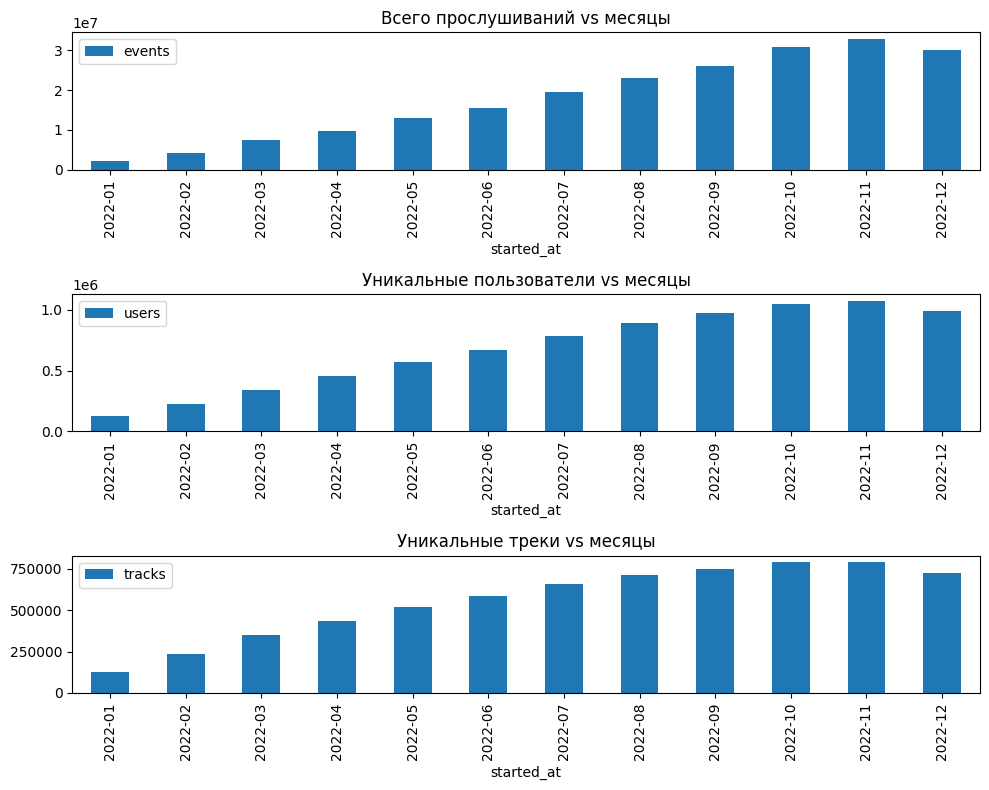

In [15]:
interactions_by_month = interactions.groupby(interactions['started_at'].dt.to_period('M')).agg(events=('started_at', 'count'), users=('user_id', 'nunique'), tracks=('track_id', 'nunique')).reset_index()

fig, ax = plt.subplots(3, 1, figsize=(10, 8))
interactions_by_month.plot('started_at', 'events', kind='bar', title='Всего прослушиваний vs месяцы', ax=ax[0])
interactions_by_month.plot('started_at', 'users', kind='bar', title='Уникальные пользователи vs месяцы', ax=ax[1])
interactions_by_month.plot('started_at', 'tracks', kind='bar', title='Уникальные треки vs месяцы', ax=ax[2])
fig.tight_layout()

interactions_by_month

### Выводы
- количество пользователей и треков возрастают со временем, сервис набирает популярность

## Наиболее популярные треки

In [33]:
tracks_polularity = pd.DataFrame(interactions['track_id'].value_counts().sort_values(ascending=False).reset_index()).set_index('track_id') \
    .merge(
        tracks_flat_combined.set_index('track_id'),
        on='track_id',
        how='left'
    ) \
    .reset_index()

tracks_polularity

,track_id,count,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,53404,111062,Smells Like Teen Spirit,"[4367, 89708, 294911, 294912, 294914, 297393, ...",[9262],"[13, 14, 102]","[Nevermind, Nirvana, Skiing Music, Smells Like...",[Nirvana],"[alternative, rock, allrock]"
1,33311009,106921,Believer,"[4440454, 4456609, 4482682, 4882996, 5072976, ...",[675068],"[14, 102]","[Shape Of Pop, NOW That's What I Call Music, E...",[Imagine Dragons],"[rock, allrock]"
2,178529,101924,Numb,"[18113, 21924, 21940, 488052, 10009799]",[36800],"[41, 47]","[Meteora, 00s Rock Anthems]",[Linkin Park],"[numetal, metal]"
3,35505245,99490,I Got Love,"[4431303, 20559909]","[4611844, 588511]","[3, 75]",[I Got Love],"[Miyagi & Эндшпиль, Рем Дигга]","[rusrap, rap]"
4,65851540,86670,Юность,[10692414],[1554548],"[11, 20]",[Юность],[Dabro],"[pop, ruspop]"
...,...,...,...,...,...,...,...,...,...
999995,592600,5,Место для тебя,[63338],[167999],"[6, 70]",[Мечтатели],[Без Билета],"[local-indie, indie]"
999996,61201731,5,Revolution,[9527451],[33318],[16],[Hey Jude],[The Beatles],[dance]
999997,52080116,5,Majandra,"[7309145, 8078982]",[7717620],"[68, 86]","[Majandra, Goa Beach, Vol. 2 - Psytrance in Pa...",[P.A.N.D.O.R.R.A.],"[electronics, trance]"
999998,73942221,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [61]:
tracks_polularity[['count']].describe()

,count
count,1000000.000000
mean,222.629898
std,1369.930708
min,5.000000
25%,9.000000
50%,19.000000
75%,67.000000
max,111062.000000


<Axes: title={'center': 'Tracks poularity'}, xlabel='track_name'>

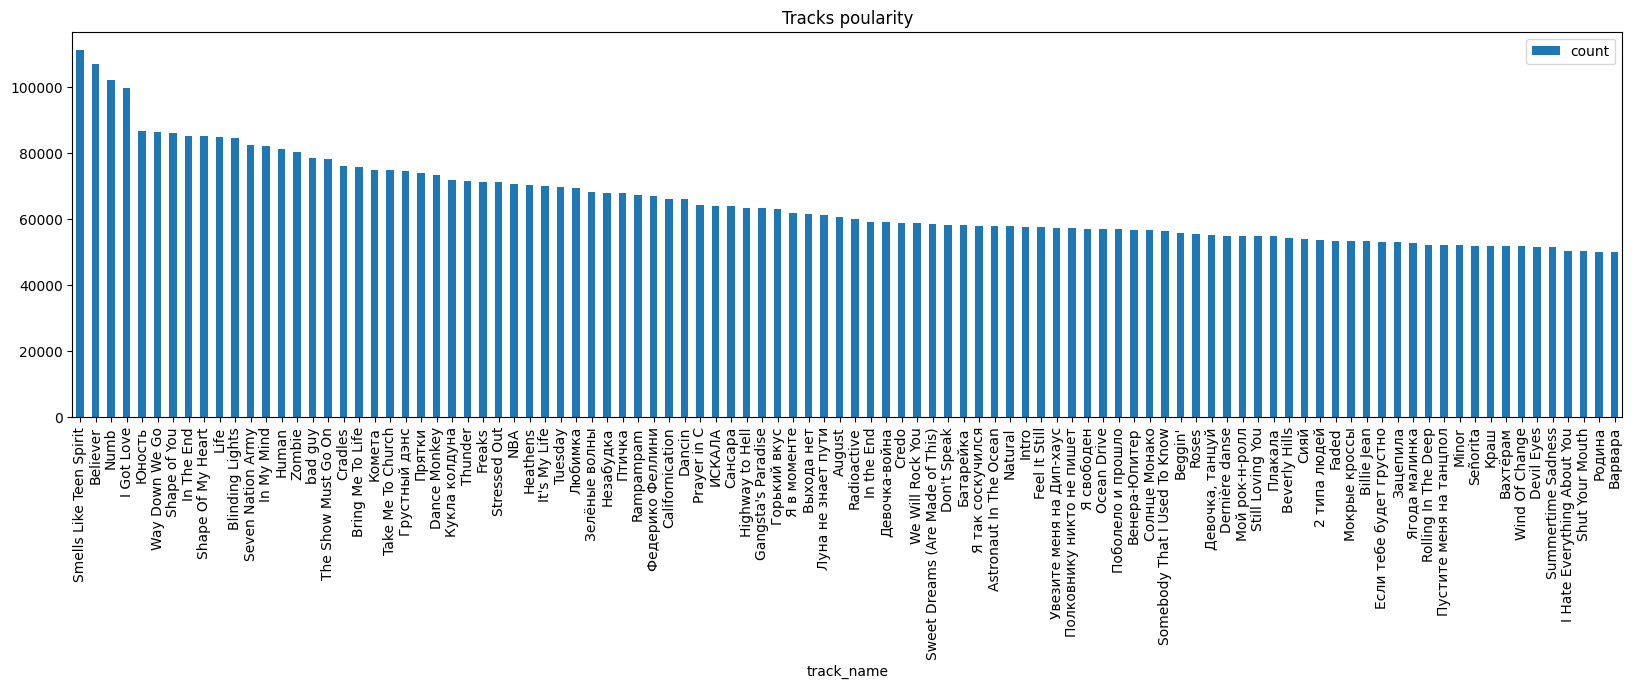

In [60]:
fig,ax = plt.subplots(1,1)
fig.set_size_inches(20,5)
tracks_polularity[['track_name', 'count']].head(100).plot(x='track_name', y='count', kind='bar', title='Tracks poularity', ax=ax)

In [34]:
# сохраним в файл
data_path = 'data/preprocess/'
tracks_polularity.to_parquet(data_path + "tracks_polularity.parquet")

### Выводы
- популярность треков убывает линейным образом от лидеров к менее популярным
- максимальная популярность достигает - 111062 прослушиваний
- минимальная популярность достигает - 5 прослушиваний

## Наиболее популярные жанры

In [3]:
# список жанров из каталога
genres = catalog.query('type == "genre"').reset_index(drop=True)
genres

,id,type,name
0,0,genre,all
1,1,genre,eastern
2,2,genre,rusrock
3,3,genre,rusrap
4,4,genre,postrock
...,...,...,...
161,1182,genre,balkan
162,1197,genre,experimental
163,1370,genre,europop
164,1484,genre,meditation


In [4]:
# сохраним в файл
data_path = 'data/preprocess/'
genres.to_parquet(data_path + "genres.parquet")

In [ ]:
# наиболее популярные жанры, исходя из взаимодействий с треками - наиболее часто встречающиеся жанры по всем взаимодействиям со всеми треками (а не топ-треков)
genres_popularity = interactions[['track_id']] \
    .merge(
        tracks_flat[['track_id', 'genre_id', 'genre_name']].drop_duplicates(),
        on='track_id',
        how='left'
    ) \
    [['genre_id', 'genre_name']].value_counts().sort_values(ascending=False).reset_index() 
       
genres_popularity

,genre_id,genre_name,count
0,11.0,pop,55551134
1,75.0,rap,37799684
2,102.0,allrock,31085569
3,20.0,ruspop,26626234
4,3.0,rusrap,25303695
...,...,...,...
126,123.0,artwork,204
127,85.0,news,166
128,90.0,society,120
129,87.0,religion,73


In [ ]:
# сохраним в файл
data_path = 'data/preprocess/'
genres_popularity['genre_id'] = genres_popularity['genre_id'].astype('int')
genres_popularity.to_parquet(data_path + "genres_popularity.parquet")

<Axes: title={'center': 'genres popularity (logscale)'}, xlabel='index,genre_name'>

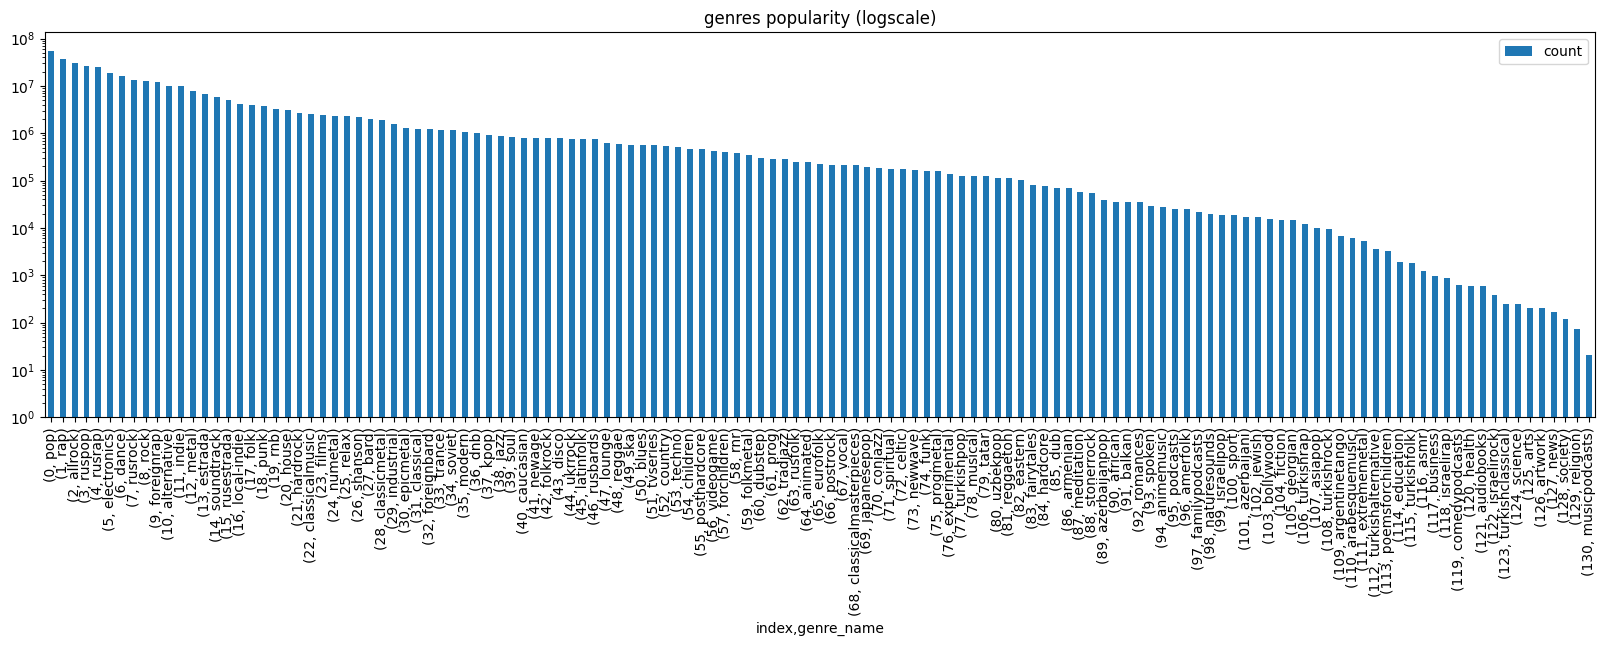

In [ ]:
fig,ax = plt.subplots(1,1)
fig.set_size_inches(20,5)
genres_popularity.reset_index()[['index', 'genre_name', 'count']].set_index(['index', 'genre_name']).plot(kind='bar', log=True, title='genres popularity (logscale)', ax=ax)

In [ ]:
genres_not_popular = genres[~genres['id'].isin(genres_popularity['genre_id'])]
print(f'genres not popular (not in history) count = {genres_not_popular.shape[0]}')
genres_not_popular

genres not popular (not in history) count = 35


,id,type,name
0,0,genre,all
34,34,genre,caribbean
36,36,genre,classic
42,42,genre,holiday
46,46,genre,latin
78,78,genre,hobbies
81,81,genre,technology
82,82,genre,government
83,83,genre,historypodcasts
91,91,genre,recreation


In [91]:
tracks_flat[tracks_flat['genre_id'].isin(genres_not_popular['id'])]

,track_id,album_id,artist_id,genre_id,track_name,album_name,artist_name,genre_name


### Вывод 
- видно что есть 35 жанров, по которым нет истории взаимодействия
    - но и треков с этими жанрами нет
- остальные 131 жанр распределены логарифмически по популярности - самые популярные на 6 порядков популярнее (от 55.551.134 до 20 прослушиваний)

## Треки, которые никто не прослушал

In [22]:
tracks_no_activity = tracks[~tracks['track_id'].isin(tracks_polularity['track_id'])]
tracks_no_activity

,track_id,albums,artists,genres


### Выводы
- треков, которые никто не прослушал, нет

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [ ]:
# дополнительных преобразований пока не требуется 
#   TODO: - возможно придется вернуться сюда на этапе проектирования рекомендательной системы
tracks_flat_combined

,track_id,track_name,album_id,artist_id,genre_id,album_name,artist_name,genre_name
0,26,Complimentary Me,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
1,38,Momma's Boy,"[3, 2490753]",[16],"[11, 21]",[Taller Children],[Elizabeth & the Catapult],"[pop, folk]"
2,135,Atticus,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
3,136,24 Hours,"[12, 214, 2490809]",[84],[11],[Wild Young Hearts],[Noisettes],[pop]
4,138,Don't Upset The Rhythm (Go Baby Go),"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11],"[Wild Young Hearts, Don't Upset The Rhythm, Hi...",[Noisettes],[pop]
...,...,...,...,...,...,...,...,...
932659,101478482,На лицо,[21399811],[5540395],"[3, 75]",[На лицо],[FLESH],"[rusrap, rap]"
932660,101490148,Без капли мысли,[21403052],[9078726],"[11, 20]",[Без капли мысли],[Даня Милохин],"[pop, ruspop]"
932661,101493057,SKITTLES,[21403883],[11865715],"[44, 75]",[SKITTLES],[WhyBaby?],"[foreignrap, rap]"
932662,101495927,Москва,[21404975],[4462686],"[3, 75]",[Москва],[Yanix],"[rusrap, rap]"


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
# сначала сохраним локально 
path = 'data/recsys/'

tracks_flat_combined.sort_values(by='track_id', ignore_index=True).to_parquet(path + "items.parquet")
interactions.sort_values(by=['user_id','started_at'], ignore_index=True).to_parquet(path + "events.parquet")


In [1]:
import pandas as pd

path = 'data/recsys/'
items = pd.read_parquet(path + "items.parquet")
events = pd.read_parquet(path + "events.parquet")

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install s3fs

# теперь сохраним в S3

s3_storage = os.getenv('S3_ENDPOINT_URL')           # https://storage.yandexcloud.net
s3_bucket = os.getenv('S3_BUCKET_NAME')             # s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4
s3_access_key = os.getenv('AWS_ACCESS_KEY_ID')      # YCAJE3Nlz8iDILW5VTYM1ihQB
s3_secret_key = os.getenv('AWS_SECRET_ACCESS_KEY')  # secret

path = "s3://" + s3_bucket + "/recsys/data/"
print(path)

# параметры подключения к S3 хранилищу
storage_options = {
    "client_kwargs": {"endpoint_url": s3_storage},
    "key": s3_access_key,  
    "secret": s3_secret_key,  
}

items.to_parquet(path + "items.parquet", storage_options=storage_options)
events.to_parquet(path + "events.parquet", storage_options=storage_options)

s3://s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4/recsys/data/


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [ ]:
# 1 - промежуточные файлы сохранены в data/preprocess 
#   - так что для EDA-анализа по этапу 2 можно загрузить файлы в начале секции "Этапа 2" 
#   - и повторить любой из этапов без необходимости выполнения исходной последовательности

# 2 - все рабочие файлы для создания рекомендательной системы сохранены в 
#   - локально - data/recsys 
#   - в S3 - https://storage.yandexcloud.net/s3-student-mle-20260306-f5465b0629-freetrack/Sprint-4/recsys/data/

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.